# Module 07 — Deep Learning in Practice
inputs: x1, x2, x3
[these connections are called weights: w1, w2, w3]

hidden layer: h1, h2, h3, h4

hidden layer: h5, h6, h7, h8

outputs: dog, cat

In [16]:
# pip install tensorflow keras

In [17]:
# tensorflow-metal is incompatible with TF 2.21.0 — uninstall it, then restart kernel
import subprocess
result = subprocess.run(['pip', 'uninstall', 'tensorflow-metal', '-y'], capture_output=True, text=True)
print(result.stdout or "tensorflow-metal not found (already removed)")
print(result.stderr)
print("Done — restart the kernel, then run the import cell.")

Found existing installation: tensorflow-metal 0.7.1
Uninstalling tensorflow-metal-0.7.1:
  Successfully uninstalled tensorflow-metal-0.7.1


Done — restart the kernel, then run the import cell.


In [ ]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist # 28x28 images of hand-written digits 0-9

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the pixel values to be between 0 and 1, easier for neural network to learn
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

model = tf.keras.models.Sequential() # feed-forward neural network (NN)
model.add(tf.keras.layers.Flatten()) # input layer: flatten 28x28 image into a 784-dimensional vector)
model.add(tf.keras.layers.Dense(128, activation='relu')) # hidden layer 1: 128 neurons, ReLU activation
model.add(tf.keras.layers.Dense(128, activation='relu')) # hidden layer 2: 128 neurons, ReLU activation
model.add(tf.keras.layers.Dense(10, activation='softmax')) # output layer: 10 neurons, softmax activation

# Parameters:
model.compile(optimizer='adam', # optimization algorithm
              loss='sparse_categorical_crossentropy', # loss function for multi-class classification
              metrics=['accuracy']) # metric to evaluate during training

# https://www.youtube.com/watch?v=wQ8BIBpya2k - 13m45s

model.fit(x_train, y_train, epochs=3) # train the model for 3 epochs (passes through the entire training dataset)

In [26]:
val_loss, val_acc = model.evaluate(x_test, y_test) # evaluate the model on the test dataset
print(val_loss, val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.9676 - loss: 0.1025
0.10246434062719345 0.9675999879837036


In [32]:
model.save('epic_num_reader.model.keras') # save the trained model to a file
new_model = tf.keras.models.load_model('epic_num_reader.model.keras') # load the model from the file
predictions = new_model.predict([x_test]) # use the model to make predictions on the test
print(predictions) # print the raw output of the model (probabilities for each class)

TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 4832566512}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [32, 28, 28], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer_1'}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Flatten', 'config': {'name': 'flatten_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'data_format': 'channels_last'}, 'reg

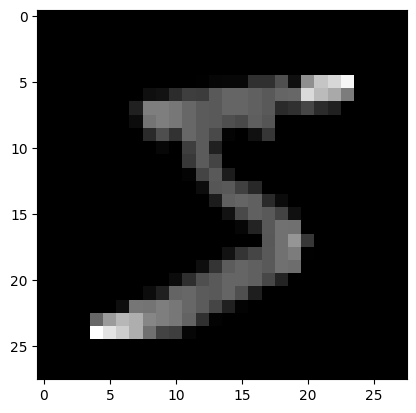

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [23]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.show()
print(x_train[0])